# 実験 01: ロジスティック写像 → 分岐図

$$x_{n+1} = r\,x_n(1-x_n), \qquad x_n\in[0,1],\ r\in[0,4]$$

たった 1 行の非線形写像から、不動点 → 周期倍分岐 → カオスへの遷移が現れる。
理論は `../../notes/nonlinear_dynamics.md` を参照。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 日本語フォント (IPAGothic) を登録して豆腐(□)を防ぐ
_jp = "/usr/share/fonts/truetype/fonts-japanese-gothic.ttf"
try:
    fm.fontManager.addfont(_jp)
    plt.rcParams["font.family"] = fm.FontProperties(fname=_jp).get_name()
except Exception as e:
    print("日本語フォント登録に失敗:", e)
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (8, 4)

def logistic(x, r):
    return r * x * (1.0 - x)

def orbit(r, x0=0.5, n=200):
    xs = np.empty(n)
    x = x0
    for i in range(n):
        x = logistic(x, r)
        xs[i] = x
    return xs

print("setup done")

setup done


## 1. 時系列

代表的な $r$ での軌道。$r$ を上げるにつれ「収束 → 周期 2 → 周期 4 → カオス」と質的に変わる。

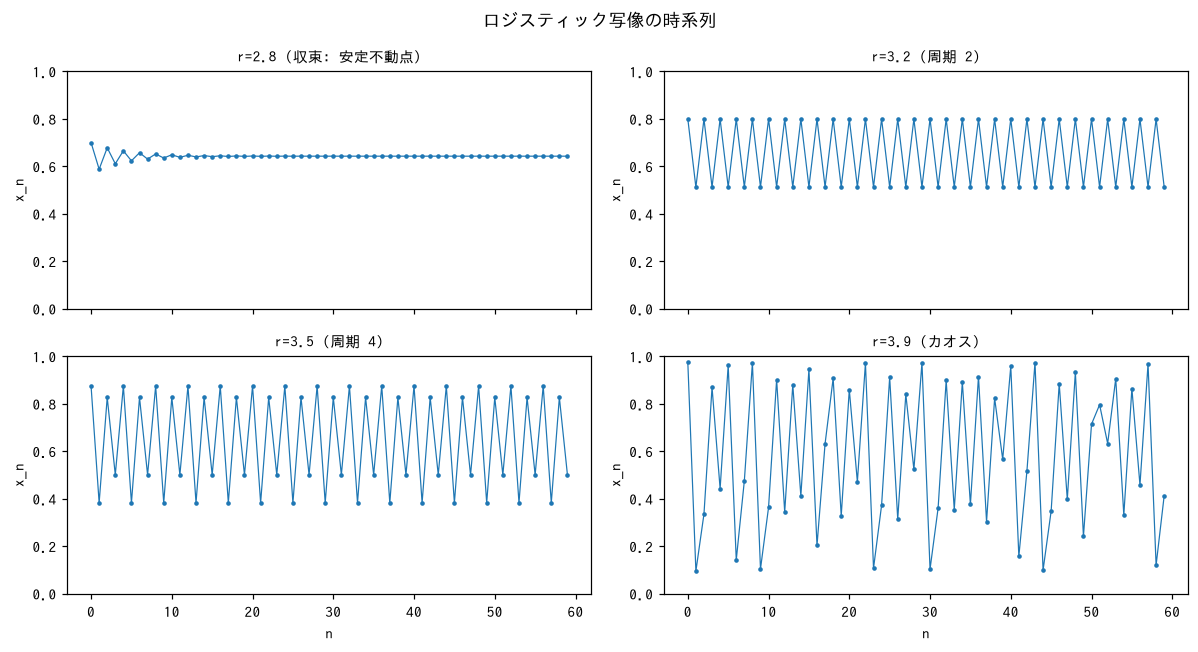

In [2]:
rs = [2.8, 3.2, 3.5, 3.9]
labels = ["r=2.8 (収束: 安定不動点)", "r=3.2 (周期 2)",
          "r=3.5 (周期 4)", "r=3.9 (カオス)"]

fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True)
for ax, r, lab in zip(axes.ravel(), rs, labels):
    xs = orbit(r, n=60)
    ax.plot(xs, ".-", lw=0.8, ms=4)
    ax.set_title(lab, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_ylabel("x_n")
axes[1, 0].set_xlabel("n"); axes[1, 1].set_xlabel("n")
fig.suptitle("ロジスティック写像の時系列", fontsize=12)
fig.tight_layout()
plt.show()

## 2. コブウェブ図

写像 $y=f(x)$ と対角線 $y=x$ の間で、$x\to f(x)\to f(x)\to\cdots$ を折れ線で追う。
交点が不動点、軌道が閉じれば周期、塗りつぶされればカオス。

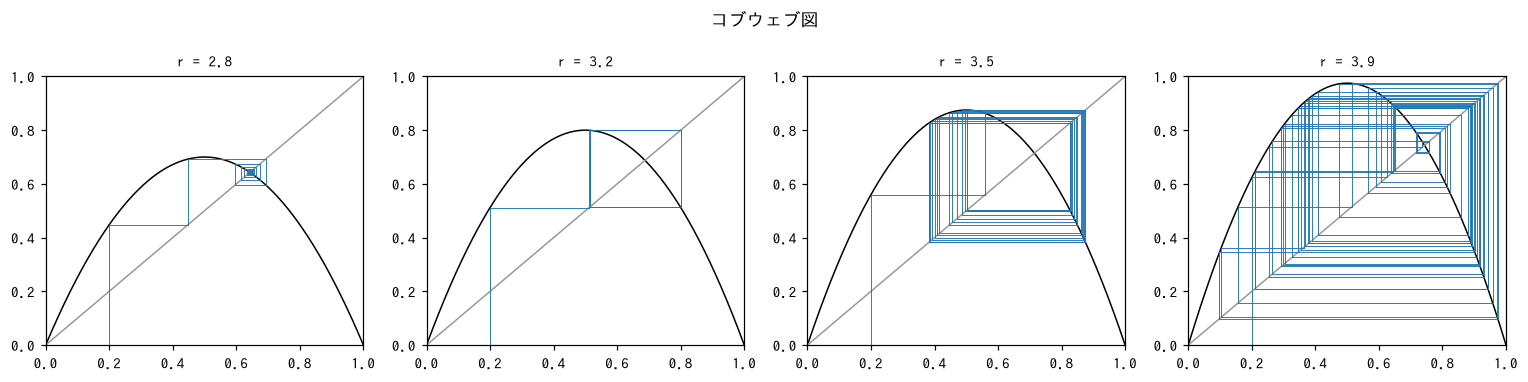

In [3]:
def cobweb(ax, r, x0=0.2, n=60):
    x = np.linspace(0, 1, 400)
    ax.plot(x, logistic(x, r), "k", lw=1)      # y = f(x)
    ax.plot(x, x, "0.6", lw=1)                  # y = x
    px, py = x0, 0.0
    for _ in range(n):
        fy = logistic(px, r)
        ax.plot([px, px], [py, fy], "C0", lw=0.6)   # 垂直: y -> f(x)
        ax.plot([px, fy], [fy, fy], "C0", lw=0.6)   # 水平: x -> f(x)
        px, py = fy, fy
    ax.set_title(f"r = {r}", fontsize=10)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, r in zip(axes, [2.8, 3.2, 3.5, 3.9]):
    cobweb(ax, r)
fig.suptitle("コブウェブ図", fontsize=12)
fig.tight_layout()
plt.show()

## 3. 分岐図

各 $r$ について過渡を捨て、長期的に訪れる $x$ の値（アトラクタ）をプロット。
周期倍分岐の連鎖と、カオス領域中の周期窓が一望できる。

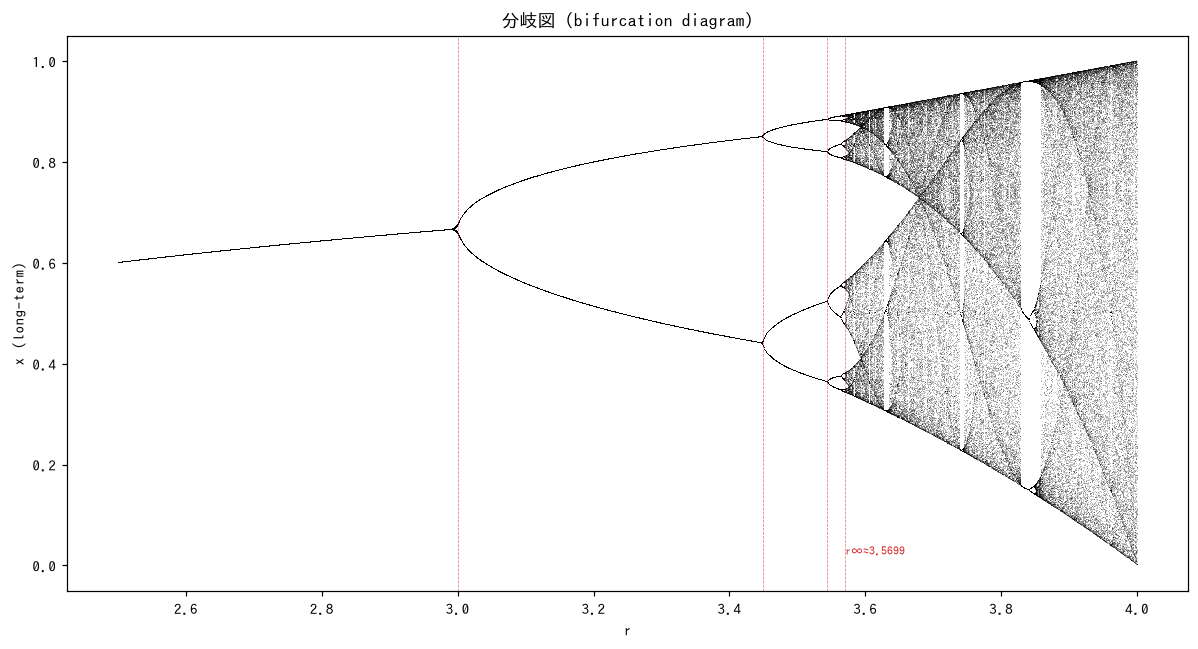

In [4]:
def bifurcation(r_min=2.5, r_max=4.0, n_r=2000, n_iter=600, n_keep=200, x0=0.5):
    rs = np.linspace(r_min, r_max, n_r)
    R, X = [], []
    for r in rs:
        x = x0
        for _ in range(n_iter - n_keep):   # 過渡を捨てる
            x = logistic(x, r)
        for _ in range(n_keep):            # 残りを記録
            x = logistic(x, r)
            R.append(r); X.append(x)
    return np.array(R), np.array(X)

R, X = bifurcation()
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(R, X, ",k", alpha=0.25)
ax.set_xlabel("r"); ax.set_ylabel("x (long-term)")
ax.set_title("分岐図 (bifurcation diagram)")
for rc in [3.0, 3.449, 3.544, 3.5699]:
    ax.axvline(rc, color="C3", lw=0.5, ls="--", alpha=0.6)
ax.text(3.57, 0.02, "r∞≈3.5699", color="C3", fontsize=8)
fig.tight_layout()
plt.show()

## 4. Lyapunov 指数 $\lambda(r)$

$$\lambda = \lim_{N\to\infty}\frac1N\sum_{n}\ln|f'(x_n)|,\qquad f'(x)=r(1-2x)$$

$\lambda<0$ は周期的（予測可能）、$\lambda>0$ はカオス（初期値鋭敏）。
分岐図と並べると、$\lambda$ が 0 を上にまたぐ点でカオスに入ることが見える。

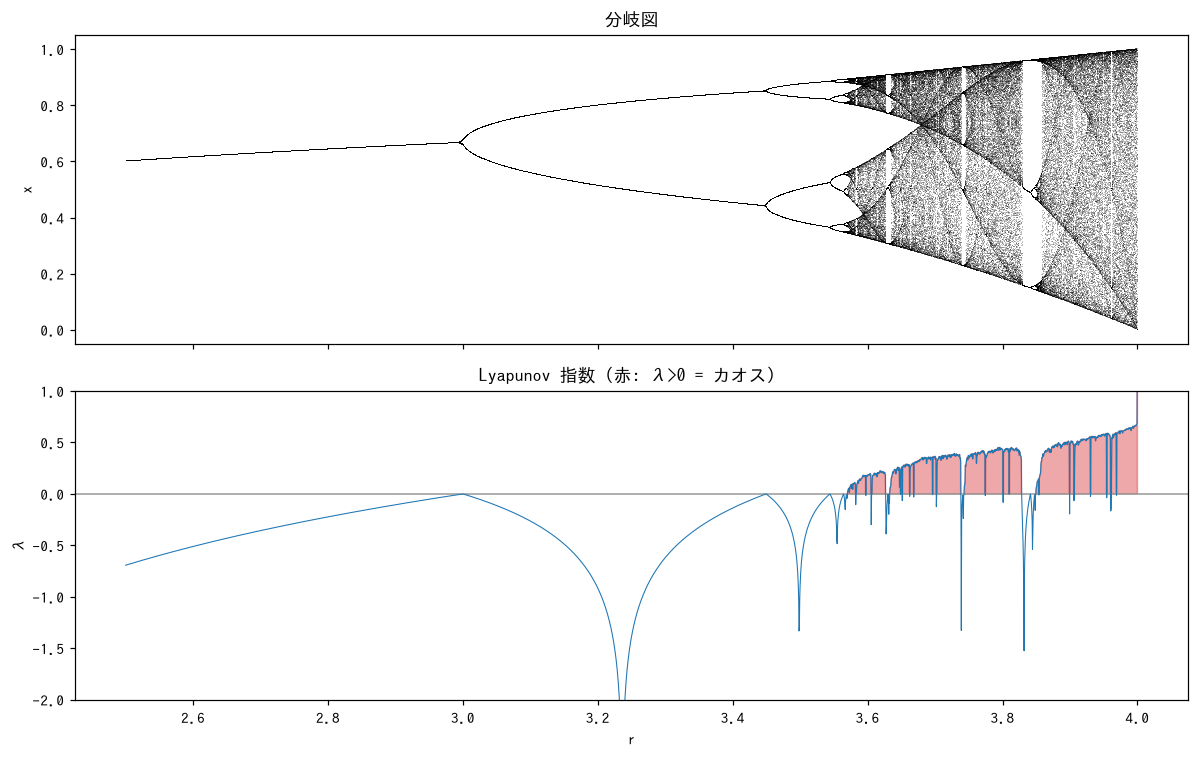

In [5]:
def lyapunov(rs, n_iter=2000, n_skip=500, x0=0.5):
    lam = np.empty_like(rs)
    for i, r in enumerate(rs):
        x = x0
        for _ in range(n_skip):
            x = logistic(x, r)
        s = 0.0
        for _ in range(n_iter):
            x = logistic(x, r)
            s += np.log(abs(r * (1 - 2 * x)) + 1e-12)
        lam[i] = s / n_iter
    return lam

rs = np.linspace(2.5, 4.0, 3000)
lam = lyapunov(rs)

fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
a1.plot(R, X, ",k", alpha=0.25); a1.set_ylabel("x"); a1.set_title("分岐図")
a2.axhline(0, color="0.6", lw=1)
a2.plot(rs, lam, "C0", lw=0.7)
a2.fill_between(rs, lam, 0, where=(lam > 0), color="C3", alpha=0.4)
a2.set_ylim(-2, 1); a2.set_xlabel("r"); a2.set_ylabel("λ")
a2.set_title("Lyapunov 指数（赤: λ>0 = カオス）")
fig.tight_layout()
plt.show()

## 5. ファイゲンバウム定数の数値推定

周期倍分岐が起きる $r_k$ の間隔比

$$\delta=\lim_{k\to\infty}\frac{r_k-r_{k-1}}{r_{k+1}-r_k}\approx 4.6692\ldots$$

は写像の詳細に依らない**普遍定数**。ここでは超安定周期点（軌道に $x=1/2$ を含む = $f'=0$ で収束最速）の $r$ を求めて比を取る。

In [6]:
from scipy.optimize import brentq

def superstable_r(period, lo, hi, n=4000):
    # x=1/2 が周期 period の点となる r。g(r)=f^period(1/2)-1/2 の符号変化を
    # 区間内で自動検出し（最大 r 側を採用）、brentq で精密化する。
    def g(r):
        x = 0.5
        for _ in range(period):
            x = logistic(x, r)
        return x - 0.5
    rs = np.linspace(lo, hi, n)
    gs = np.array([g(r) for r in rs])
    idx = np.where(np.diff(np.sign(gs)) != 0)[0]
    i = idx[-1]
    return brentq(g, rs[i], rs[i + 1])

# 周期 2^k の超安定点を囲む探索窓
windows = {1: (1.5, 2.5), 2: (3.0, 3.3), 4: (3.4, 3.52),
           8: (3.54, 3.5565), 16: (3.566, 3.5675), 32: (3.5690, 3.56925)}
Rs = {p: superstable_r(p, lo, hi) for p, (lo, hi) in windows.items()}
for p in sorted(Rs):
    print(f"周期 {p:>2}: r = {Rs[p]:.7f}")

vals = [Rs[k] for k in sorted(Rs)]
print("\nδ の推定 (超安定 r_k 間隔の比):")
for i in range(1, len(vals) - 1):
    delta = (vals[i] - vals[i-1]) / (vals[i+1] - vals[i])
    print(f"  周期 {2**i:>2}→{2**(i+1):>2}: δ ≈ {delta:.4f}")
print("\n真値 δ ≈ 4.6692016...（写像によらない普遍定数）")

周期  1: r = 2.0000000
周期  2: r = 3.2360680
周期  4: r = 3.4985617
周期  8: r = 3.5546409
周期 16: r = 3.5666674
周期 32: r = 3.5692435

δ の推定 (超安定 r_k 間隔の比):
  周期  2→ 4: δ ≈ 4.7089
  周期  4→ 8: δ ≈ 4.6808
  周期  8→16: δ ≈ 4.6630
  周期 16→32: δ ≈ 4.6684

真値 δ ≈ 4.6692016...（写像によらない普遍定数）


## まとめ・気づき

- **1 次元・1 パラメータの決定論的写像**から、周期倍分岐を経てカオスが生まれる。
- **分岐図と $\lambda(r)$ は完全対応**：$\lambda$ が 0 を上にまたぐ所でカオス突入、$\lambda<0$ に戻る所が周期窓。
- **ファイゲンバウム定数 $\delta\approx4.669$** は写像によらない普遍定数 → 「ミクロの詳細に依らないマクロな法則性」という複雑系の中心テーマの最初の実例。
- 初期値鋭敏性（$\lambda>0$）は、決定論的でも長期予測が原理的に不能であることを意味する。

**次へ**: 実験 02（Kuramoto 同期 / marimo）では、同じ「分岐・臨界」を**スライダーで対話的に**探り、Jupyter との使い分けを体感する。